#  Programming Assignment 2
Ritabrata Mandal-EE25S009

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.linalg import toeplitz
import os

### Image Loading

In [2]:
os.makedirs("output", exist_ok=True)
image = plt.imread('data/fish.png')
image_car = plt.imread('data/redcar.png')
image_background = plt.imread('data/background.png')
print(image.max())
print(image_car.max())
# plt.imshow(image); plt.axis('off'); plt.title("Original Image");plt.show()
# plt.imshow(image_car); plt.axis('off'); plt.title("Original Image");plt.show()
print(image.shape, image_car.shape, image_background.shape)  

1.0
0.827451
(450, 800, 3) (360, 600, 3) (360, 600, 3)


### Data Loading

In [3]:
gaussian_noise = sio.loadmat('data/gaussNoise.mat')
code_sequence = sio.loadmat('data/codeSeq.mat')
CameraT = sio.loadmat('data/CameraT.mat') 
gaussNoise = gaussian_noise['gaussNoise']
codeSeq_1 = code_sequence['codeSeq']
codeSeq_2 = np.array([[1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]])
CameraT = CameraT['CameraT']
print(codeSeq_1.shape)
print(codeSeq_2.shape)
print(CameraT.shape)

(1, 52)
(1, 52)
(1, 53)


### Helper functions

In [4]:
def generate_motion_blur(
    image: np.ndarray,
    gauss_noise: np.ndarray,
    codeSeq: np.ndarray = np.ones((1, 52)),
) -> np.ndarray:
    """
    Generates a blurred image and adds a pre-loaded 3D noise array.

    Argsuments:
        image (np.ndarray): The input image array of shape (m, n, 3).
        gauss_noise (np.ndarray): The noise array of shape (m, n + exposure - 1, 3).
        codeSeq (np.ndarray): The code sequence array of shape (1,exposure).

    Returns:
        np.ndarray: The final blurred and noisy image of shape (m, n + exp - 1, 3).
    """
    exposure = codeSeq.shape[1]
    if image.dtype == np.uint8:
        image = image.astype(np.float32) / 255.0

    m, n, channels = image.shape
    blurred_image = np.zeros((m, n + exposure - 1, channels), dtype=np.float32)

    for t in range(exposure):
        if codeSeq[0, t] == 1:
            blurred_image[:, t:t+n, :] += image
    blurred_image /= np.sum(codeSeq)
    blurred_image *= 255.0

    if gauss_noise.shape == blurred_image.shape:
         blurred_image += gauss_noise
    else:
        raise ValueError(f"Noise shape {gauss_noise.shape} does not match "
                         f"blurred image shape {blurred_image.shape}.")

    blurred_image = blurred_image / 255.0
    return blurred_image.clip(0, 1)

def create_toeplitz_matrix(n: int, codeSeq: np.ndarray = np.ones((1, 52))) -> np.ndarray:
    """
    Creates a normalized Toeplitz matrix representing the motion blur operation.
    
    Arguments:
        n (int): width of the image
        codeSeq (np.ndarray): The code sequence array of shape (1, exposure).
        
    Returns:
        np.ndarray: The Toeplitz matrix of shape (n + exposure - 1, n).
    """
    exposure = codeSeq.shape[1]
    norm_factor = np.sum(codeSeq)
    normalized_seq = codeSeq.flatten() / norm_factor

    c = np.zeros(n + exposure - 1)
    c[:exposure] = normalized_seq

    r = np.zeros(n)
    r[0] = normalized_seq[0]

    return toeplitz(c, r)

def reconstruct_with_inverse(blurred_image: np.ndarray, A: np.ndarray) -> np.ndarray:
    """
    Reconstructs the image by lease squares.
    Arguments:
        blurred_image (np.ndarray): The blurred image of shape (m, n + exposure - 1, 3).
        A (np.ndarray): The toeplitz matrix of shape (n + exposure - 1, n).
    """
    m, _ , channels = blurred_image.shape
    input_width = A.shape[1] # This is 'n'
    
    AtA = A.T @ A
    AtA_inv = np.linalg.inv(AtA)
    
    A_pinv = AtA_inv @ A.T  
    reconstructed_image = np.zeros((m, input_width, channels))
    
    for c in range(channels):
        y_channel = blurred_image[:, :, c]
        reconstructed_rows_T = A_pinv @ y_channel.T
        reconstructed_image[:, :, c] = reconstructed_rows_T.T
        
    return reconstructed_image.clip(0, 1)
    
def rmse(original: np.ndarray, reconstructed: np.ndarray) -> float:
    """
    Computes the Root Mean Square Error between the original and reconstructed images.
    Arguments:
        original (np.ndarray): The original image of shape (m, n, 3).
        reconstructed (np.ndarray): The reconstructed image of shape (m, n, 3).
    Returns:
        float: The RMSE value.
    """
    return np.sqrt(np.mean((original.astype(np.float32) - reconstructed.astype(np.float32)) ** 2))

def generate_motion_invariant_blur(
    background_img: np.ndarray,
    foreground_img: np.ndarray,
    exposure_time: int,
    camera_translations: np.ndarray = np.zeros((1,52)).flatten()
) -> np.ndarray:
    """
    Generates a motion blur considering both object and camera movement.
    Arguments:
        background_img (np.ndarray): The background image of shape (m, n, 3).
        foreground_img (np.ndarray): The foreground image of shape (m, n, 3).
        exposure_time (int): The exposure time.
        camera_translations (np.ndarray): The camera translations of shape (1, exposure).
    Returns:
        np.ndarray: The final blurred image of shape (m, n, 3).
    """
    bg_h, bg_w, _ = background_img.shape
    fg_h, fg_w, _ = foreground_img.shape
    padding = int(np.max(np.abs(camera_translations))) + exposure_time
    final_width = bg_w + 2 * padding
    frame_accumulator = np.zeros((bg_h, final_width, 3), dtype=np.float64)
    mask = np.any(foreground_img > 0, axis=2)
    for t in range(exposure_time):
        current_frame = np.zeros((bg_h, final_width, 3), dtype=np.float64)
        bg_translation = camera_translations[t]
        bg_x_start = padding + int(round(bg_translation))
        bg_x_end = bg_x_start + bg_w
        current_frame[:, bg_x_start:bg_x_end, :] = background_img.astype(np.float64)
        object_translation = t
        relative_translation = bg_translation - object_translation
        fg_x_start = padding + int(round(relative_translation))
        fg_x_end = fg_x_start + fg_w
        frame_slice = current_frame[0:fg_h, fg_x_start:fg_x_end]
        if frame_slice.shape[1] == fg_w:
            frame_slice[mask] = foreground_img[mask].astype(np.float64)
        frame_accumulator += current_frame
    blurred_image_wide = frame_accumulator / exposure_time
    final_blurred_image = blurred_image_wide[:, padding : padding + bg_w, :]
    # final_blurred_image = blurred_image_wide
    return final_blurred_image.clip(0, 1)


### 1. Motion deblurring with conventional camera



#### (a) Blurred Image

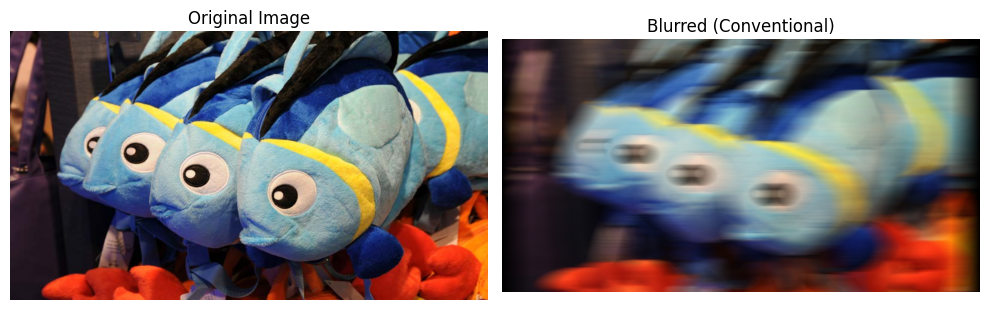

In [5]:
blurred_image_with_noise = generate_motion_blur(image, gaussNoise)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image); ax[0].axis("off"); ax[0].set_title("Original Image")
ax[1].imshow(blurred_image_with_noise); ax[1].axis("off"); ax[1].set_title("Blurred (Conventional)")
plt.tight_layout()

fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[0].images[0]; ax_single.imshow(im.get_array()); ax_single.axis("off"); ax_single.set_title(ax[0].get_title())
fig_single.savefig("output/original.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)

fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[1].images[0]; ax_single.imshow(im.get_array()); ax_single.axis("off"); ax_single.set_title(ax[1].get_title())   
fig_single.savefig("output/blurred_conventional.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
plt.show()
# print(blurred_image_with_noise.max())

#### (b) Toeplitz Matrix

(851, 800)


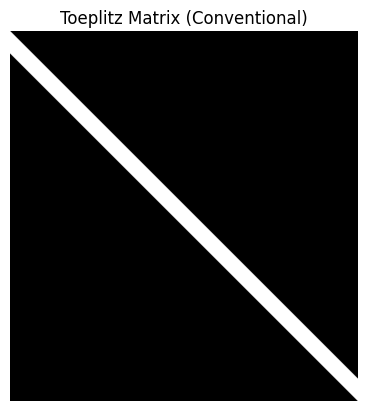

In [6]:
n= image.shape[1]
A = create_toeplitz_matrix(n)
print(A.shape)
plt.imshow(A, cmap='gray'); plt.axis('off'); plt.title(f"Toeplitz Matrix (Conventional)")
plt.savefig("output/toeplitz_matrix_convemtional.pdf", format="pdf", bbox_inches="tight");plt.show()

#### (c) Deblurred Image & RMSE

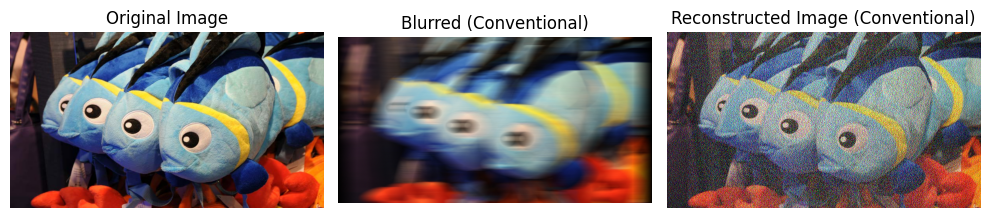

RMSE with code sequence '1111111111111111111111111111111111111111111111111111' is: 0.3335970938205719


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
x_hat_conv = reconstruct_with_inverse(blurred_image_with_noise, A)
ax[0].imshow(image); ax[0].axis('off'); ax[0].set_title("Original Image")
ax[1].imshow(blurred_image_with_noise); ax[1].axis('off'); ax[1].set_title("Blurred (Conventional)")
ax[2].imshow(x_hat_conv); ax[2].axis('off'); ax[2].set_title("Reconstructed Image (Conventional)")

fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[2].images[0]   
ax_single.imshow(im.get_array())
ax_single.axis("off")
ax_single.set_title(ax[2].get_title())

fig_single.savefig("output/reconstructed_conventional.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
plt.tight_layout(); plt.show()

code_str_conv = "".join(np.ones((1,52)).flatten().astype(int).astype(str))
print(f"RMSE with code sequence '{code_str_conv}' is: {rmse(image, x_hat_conv)}")

#### (d) Observation & Results
In the deblurred image, a significant amount of noise is visible. This occurs because the pseudo-inverse of the A matrix amplifies the high-frequency components, which in turn amplifies the noise. As a result we see the RMSE of the original image and the reconstucted image is not zero.

### 2. Motion deblurring with flutter shutter

#### (a) Blurred Image

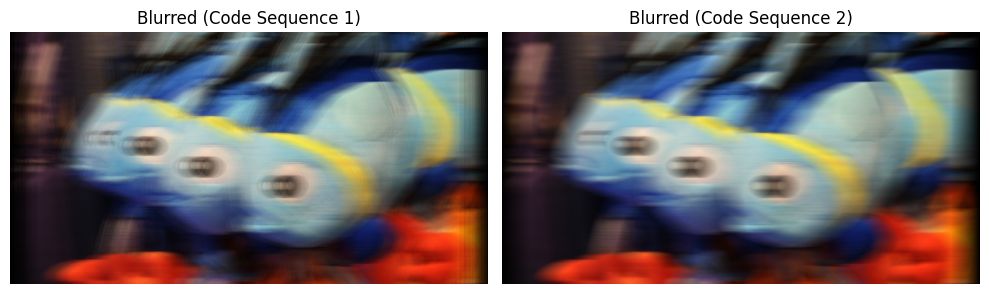

In [8]:
blurred_with_seq_1 = generate_motion_blur(image, gaussNoise, codeSeq_1)
blurred_with_seq_2 = generate_motion_blur(image, gaussNoise, codeSeq_2)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(blurred_with_seq_1); ax[0].axis("off"); ax[0].set_title("Blurred (Code Sequence 1)")
ax[1].imshow(blurred_with_seq_2); ax[1].axis("off"); ax[1].set_title("Blurred (Code Sequence 2)")
plt.tight_layout()


fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[0].images[0]; ax_single.imshow(im.get_array()); ax_single.axis("off"); ax_single.set_title(ax[0].get_title())
fig_single.savefig("output/blurred_seq_1.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[1].images[0]; ax_single.imshow(im.get_array()); ax_single.axis("off"); ax_single.set_title(ax[1].get_title())
fig_single.savefig("output/blurred_seq_2.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
plt.show()


#### (b) Toeplitz Matrix

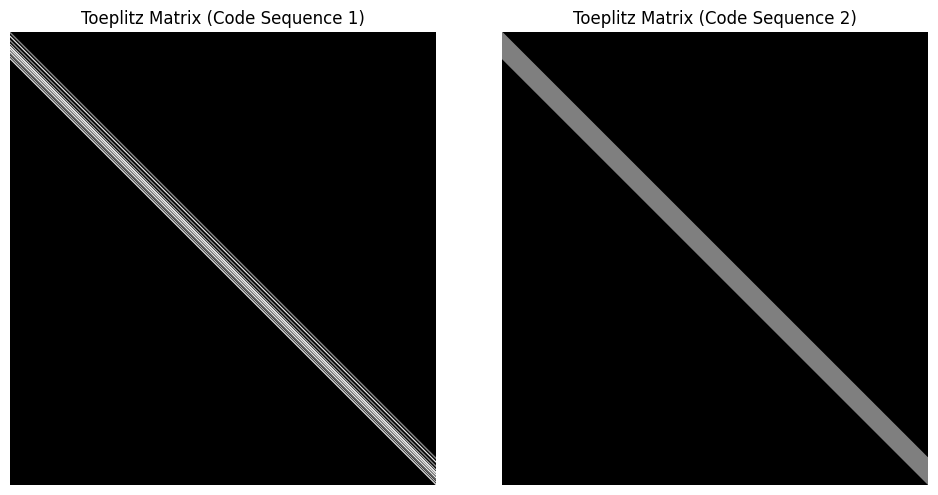

In [9]:
A1 = create_toeplitz_matrix(image.shape[1],codeSeq=codeSeq_1)
A2 = create_toeplitz_matrix(image.shape[1],codeSeq=codeSeq_2)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(A1, cmap='gray'); ax[0].axis('off'); ax[0].set_title(f"Toeplitz Matrix (Code Sequence 1)")
ax[1].imshow(A2, cmap='gray'); ax[1].axis('off'); ax[1].set_title(f"Toeplitz Matrix (Code Sequence 2)")
plt.tight_layout()

fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[0].images[0]; ax_single.imshow(im.get_array(), cmap='gray'); ax_single.axis("off"); ax_single.set_title(ax[0].get_title())
fig_single.savefig("output/toeplitz_matrix_seq_1.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[1].images[0]; ax_single.imshow(im.get_array(), cmap='gray'); ax_single.axis("off"); ax_single.set_title(ax[1].get_title())
fig_single.savefig("output/toeplitz_matrix_seq_2.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)

plt.show()


#### (c) DFT of conventional and codeSequence_1&2 kernels

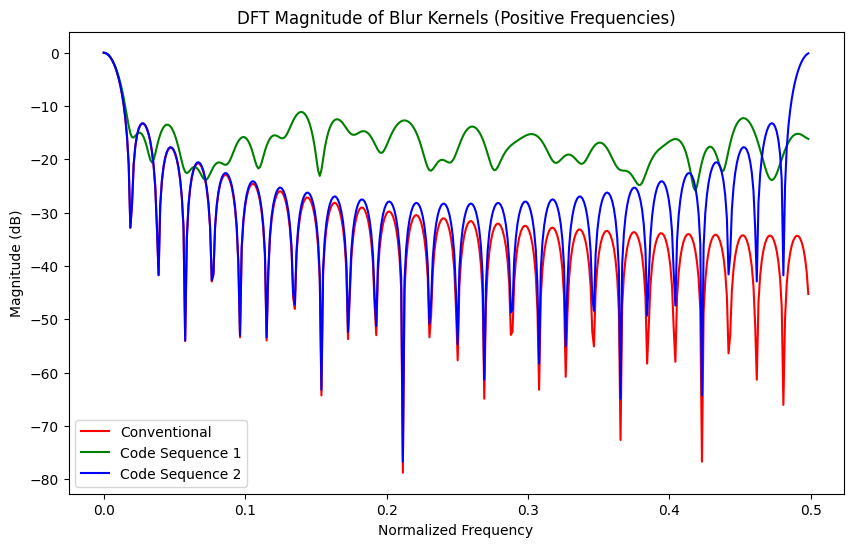

In [10]:
kernel_conv = A[:,0]
kernel_seq_1 = A1[:,0]
kernel_seq_2 = A2[:,0]

padded_length = 851
dft_conv = np.fft.fft(kernel_conv, n=padded_length)
dft_seq_1 = np.fft.fft(kernel_seq_1, n=padded_length)
dft_seq_2 = np.fft.fft(kernel_seq_2, n=padded_length)

mag_conv = np.abs(dft_conv) + 1e-10
mag_seq_1 = np.abs(dft_seq_1) + 1e-10
mag_seq_2 = np.abs(dft_seq_2) + 1e-10
db_conv = 20 * np.log10(mag_conv)
db_seq_1 = 20 * np.log10(mag_seq_1)
db_seq_2 = 20 * np.log10(mag_seq_2)

freq_axis = np.fft.fftfreq(padded_length)

num_positive_freqs = padded_length // 2
freq_positive = freq_axis[:num_positive_freqs]
db_conv_positive = db_conv[:num_positive_freqs]
db_seq_1_positive = db_seq_1[:num_positive_freqs]
db_seq_2_positive = db_seq_2[:num_positive_freqs]

fig = plt.figure(figsize=(10, 6))
plt.plot(freq_positive, db_conv_positive, label='Conventional', color='red')
plt.plot(freq_positive, db_seq_1_positive, label='Code Sequence 1', color='green')
plt.plot(freq_positive, db_seq_2_positive, label='Code Sequence 2', color='blue')

plt.title('DFT Magnitude of Blur Kernels (Positive Frequencies)')
plt.xlabel('Normalized Frequency'); plt.ylabel('Magnitude (dB)'); plt.legend()
# plt.grid(True)
plt.savefig("output/dft_magnitude_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### (d) Deblurred Image

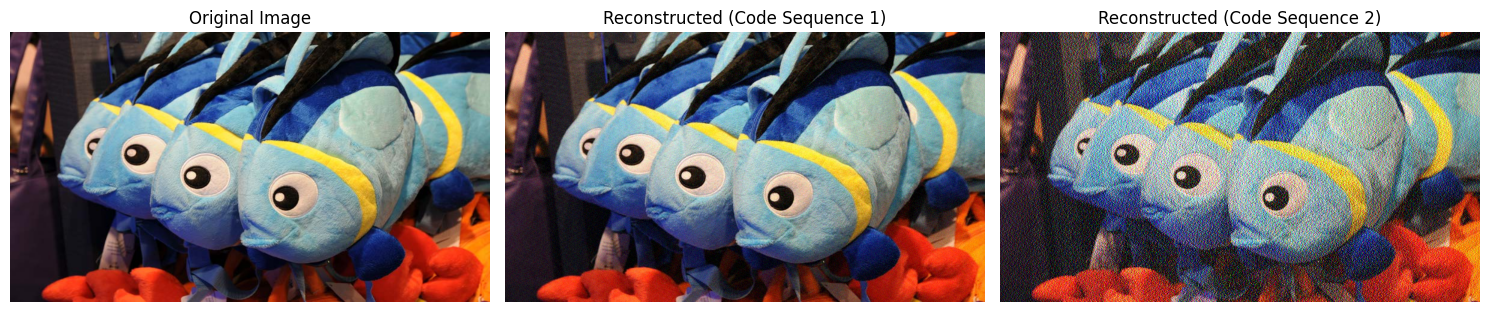

In [11]:
x_hat_1 = reconstruct_with_inverse(blurred_with_seq_1, A1)
x_hat_2 = reconstruct_with_inverse(blurred_with_seq_2, A2)

fig, ax = plt.subplots(1, 3, figsize=(15, 10))
ax[0].imshow(image); ax[0].axis("off"); ax[0].set_title("Original Image")
ax[1].imshow(x_hat_1); ax[1].axis("off"); ax[1].set_title("Reconstructed (Code Sequence 1)")
ax[2].imshow(x_hat_2); ax[2].axis("off"); ax[2].set_title("Reconstructed (Code Sequence 2)")
plt.tight_layout()
fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[1].images[0]; ax_single.imshow(im.get_array(), cmap='gray'); ax_single.axis("off"); ax_single.set_title(ax[1].get_title())
fig_single.savefig("output/reconstructed_seq_1.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
fig_single, ax_single = plt.subplots(figsize=(5, 5))
im = ax[2].images[0]; ax_single.imshow(im.get_array(), cmap='gray'); ax_single.axis("off"); ax_single.set_title(ax[2].get_title())
fig_single.savefig("output/reconstructed_seq_2.pdf", format="pdf", bbox_inches="tight")
plt.close(fig_single)
plt.show()

#### (e) RMSE & result comparison

In [12]:
code_str_1 = "".join(codeSeq_1.flatten().astype(int).astype(str))
code_str_2 = "".join(codeSeq_2.flatten().astype(int).astype(str))
print(f"RMSE with code sequence '{code_str_1}' is: {rmse(image, x_hat_1)}")
print(f"RMSE with code sequence '{code_str_2}' is: {rmse(image, x_hat_2)}")

RMSE with code sequence '1010000111000001010000110011110111010111001001100111' is: 0.03346693515777588
RMSE with code sequence '1010101010101010101010101010101010101010101010101010' is: 0.20334821939468384


For the reconstructed image using code_sequence-1, we observe less noise compared to code_sequence-2. This is because the DFT of the first sequence is more broadband, leading to reduced amplification of the Gaussian noise added to the blurred image. The RMSE values also support this observation: 0.033 for code_sequence-1 versus 0.2033 for code_sequence-2.

#### (f) Reconstruction without noise added

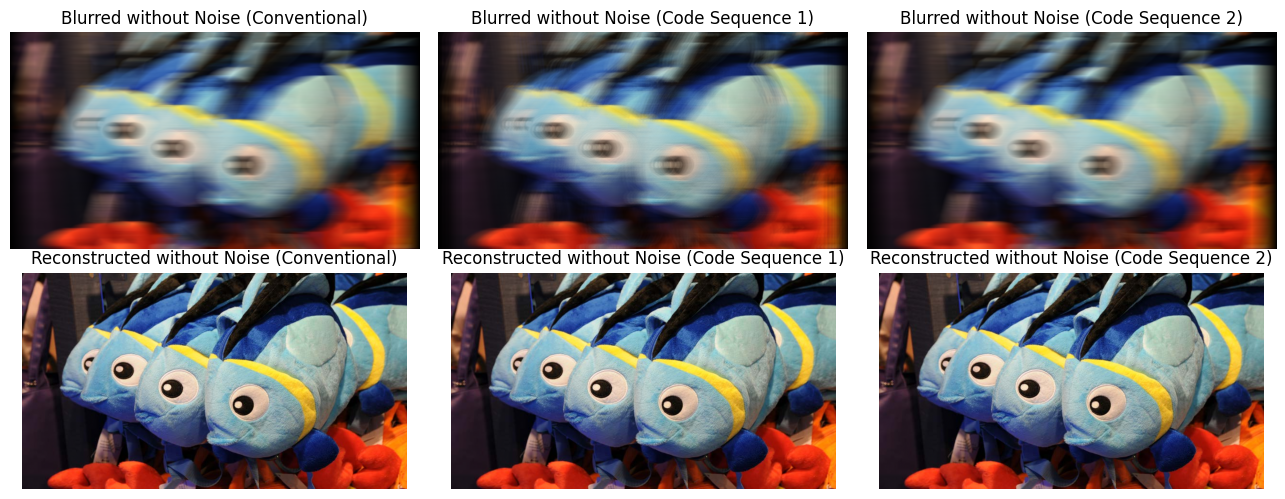

In [13]:
blurred_image_conv_without_noise = generate_motion_blur(image, np.zeros_like(gaussNoise))
blurred_image_seq_1_without_noise = generate_motion_blur(image, np.zeros_like(gaussNoise), codeSeq_1)
blurred_image_seq_2_without_noise = generate_motion_blur(image, np.zeros_like(gaussNoise), codeSeq_2)

x_hat_without_noise = reconstruct_with_inverse(blurred_image_conv_without_noise, A)
x_hat_seq_1_without_noise = reconstruct_with_inverse(blurred_image_seq_1_without_noise, A1)
x_hat_seq_2_without_noise = reconstruct_with_inverse(blurred_image_seq_2_without_noise, A2)

fig, ax = plt.subplots(2, 3, figsize=(13, 5))
ax[0,0].imshow(blurred_image_conv_without_noise); ax[0,0].axis("off"); ax[0,0].set_title("Blurred without Noise (Conventional)")
ax[0,1].imshow(blurred_image_seq_1_without_noise); ax[0,1].axis("off"); ax[0,1].set_title("Blurred without Noise (Code Sequence 1)")
ax[0,2].imshow(blurred_image_seq_2_without_noise); ax[0,2].axis("off"); ax[0,2].set_title("Blurred without Noise (Code Sequence 2)")
ax[1,0].imshow(x_hat_without_noise); ax[1,0].axis("off"); ax[1,0].set_title("Reconstructed without Noise (Conventional)")
ax[1,1].imshow(x_hat_seq_1_without_noise); ax[1,1].axis("off"); ax[1,1].set_title("Reconstructed without Noise (Code Sequence 1)")
ax[1,2].imshow(x_hat_seq_2_without_noise); ax[1,2].axis("off"); ax[1,2].set_title("Reconstructed without Noise (Code Sequence 2)")
plt.tight_layout()
plt.show()
images_to_save = {
    "output/blurred_conventional_without_noise.pdf": (blurred_image_conv_without_noise, "Blurred without Noise (Conventional)"),
    "output/blurred_seq_1_without_noise.pdf": (blurred_image_seq_1_without_noise, "Blurred without Noise (Code Sequence 1)"),
    "output/blurred_seq_2_without_noise.pdf": (blurred_image_seq_2_without_noise, "Blurred without Noise (Code Sequence 2)"),
    "output/reconstructed_conventional_without_noise.pdf": (x_hat_without_noise, "Reconstructed without Noise (Conventional)"),
    "output/reconstructed_seq_1_without_noise.pdf": (x_hat_seq_1_without_noise, "Reconstructed without Noise (Code Sequence 1)"),
    "output/reconstructed_seq_2_without_noise.pdf": (x_hat_seq_2_without_noise, "Reconstructed without Noise (Code Sequence 2)")
}

for filename, (image_array, title) in images_to_save.items():
    fig, ax = plt.subplots()
    ax.imshow(image_array)
    ax.set_title(title)
    ax.axis("off")
    fig.savefig(filename, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)

In this case, since the blurred image does not contain noise, the difference between the reconstructed images using the two code sequences is very subtle.

### 3. Deblurring with motion-invariant photography

#### ((a), (b)) Blurred Foregroung + Background

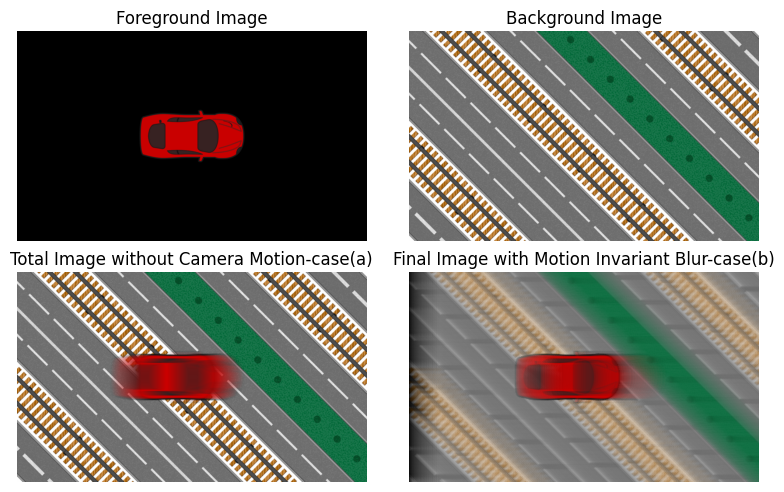

In [14]:
exposure_time = 52
camera_data = CameraT.flatten()[:exposure_time]

total_image = generate_motion_invariant_blur(
    background_img=image_background,
    foreground_img=image_car,
    exposure_time=exposure_time,
)
final_image = generate_motion_invariant_blur(
    background_img=image_background,
    foreground_img=image_car,
    exposure_time=exposure_time,
    camera_translations=camera_data
)
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0,0].imshow(image_car); ax[0,0].axis("off"); ax[0,0].set_title("Foreground Image")
ax[0,1].imshow(image_background); ax[0,1].axis("off"); ax[0,1].set_title("Background Image")
ax[1,0].imshow(total_image); ax[1,0].axis("off"); ax[1,0].set_title("Total Image without Camera Motion-case(a)")
ax[1,1].imshow(final_image); ax[1,1].axis("off"); ax[1,1].set_title("Final Image with Motion Invariant Blur-case(b)")
plt.tight_layout()
plt.imsave("output/total_image_no_motion.pdf", total_image)
plt.imsave("output/total_image_motion_invariant.pdf", final_image)
plt.show()

#### (c) Compare and comment on the outputs of (a) and (b)

In case (a), the foreground appears blurred while the background remains sharp, as both the background and the camera are stationary. In contrast, in case (b), both the foreground and background appear blurred because the camera is in motion, and the relative velocity between the camera and the foreground is non-zero.

#### (d) PSF

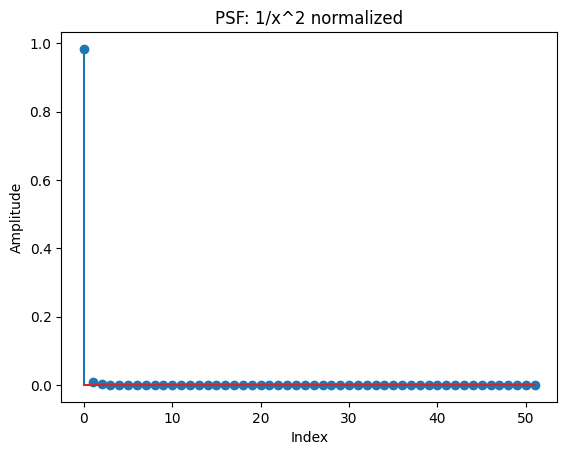

In [15]:
x_val = np.arange(52, dtype=np.float64)
x_val[0] = 0.1
psf = 1/ x_val**2
psf = psf / np.sum(psf)
plt.stem(psf); plt.title("PSF: 1/x^2 normalized"); plt.xlabel("Index"); plt.ylabel("Amplitude")
plt.savefig("output/psf_motion_invariant.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### (e) Blur Matrix(Toeplitz)

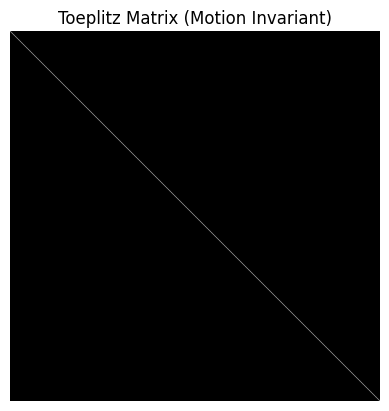

In [16]:
A_motion_invariant = create_toeplitz_matrix(final_image.shape[1], psf.reshape(1, 52))
plt.imshow(A_motion_invariant[:final_image.shape[1],:], cmap='gray'); plt.axis('off'); plt.title(f"Toeplitz Matrix (Motion Invariant)")
plt.savefig("output/toeplitz_matrix_motion_invariant.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### (f) Deblurred Image

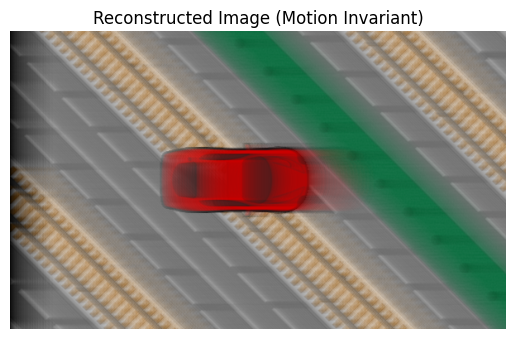

In [17]:
x_hat_motion_invariant = reconstruct_with_inverse(final_image, A_motion_invariant[:final_image.shape[1], :])
plt.imshow(x_hat_motion_invariant); plt.axis('off'); plt.title("Reconstructed Image (Motion Invariant)")
plt.savefig("output/reconstructed_motion_invariant.pdf", format="pdf", bbox_inches="tight")
plt.show()